For k= 24 , inertia value= 171.16


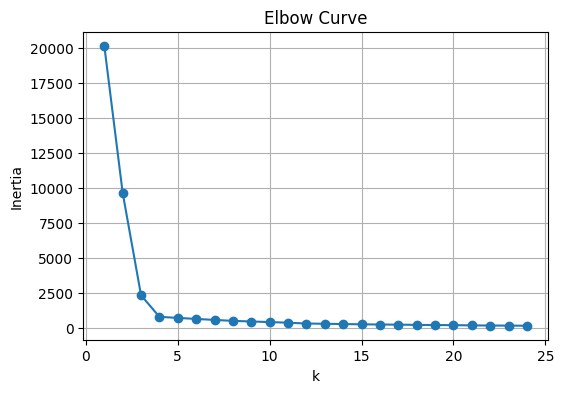

For k =24 , Silhouette score = 0.350


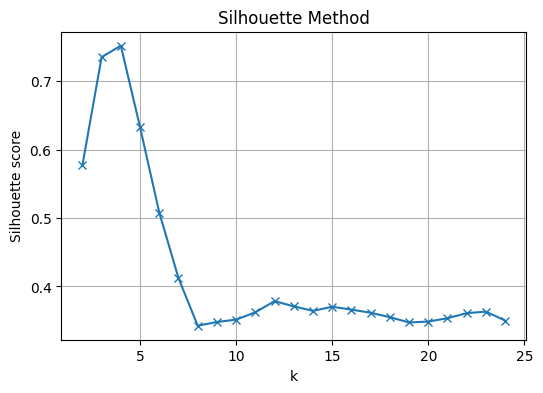

In [21]:
#IMPORTS
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
#GENERATE DATASET
x,y = make_blobs(n_samples=300, centers=4, cluster_std=1.2, random_state=42)
#ELBOW METHOD
inertia_values = []
k_values=range(1,25)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(x)
    inertia_values.append(kmeans.inertia_)
print(f"For k= {k} , inertia value= {kmeans.inertia_:.2f}")
#PLOT ELBOW CURVE
plt.figure(figsize=(6,4))
plt.plot(k_values, inertia_values, marker ='o')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Curve')
plt.grid(True)
plt.show()
#SILHOUETTE METHOD
silhouette_values = []
l_values=range(2,25)
for k in l_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels=kmeans.fit_predict(x)
    score=silhouette_score(x, labels)
    silhouette_values.append(score)
print(f"For k ={k} , Silhouette score = {score:.3f}")
#PLOT SILHOUETTE CURVE
plt.figure(figsize=(6,4))
plt.plot(l_values,silhouette_values, marker ='x')
plt.xlabel('k')
plt.ylabel('Silhouette score')
plt.title('Silhouette Method')
plt.grid(True)
plt.show()

# 🧠 K-Means Cluster Evaluation Methods

We used two popular methods to determine the **optimal number of clusters (k)** —  
the **Elbow Method** and the **Silhouette Method**.

---

## 📉 1. Elbow Method

### 🔹 Concept
The **Elbow Method** measures **inertia** — how tightly data points fit within clusters.  
As `k` increases, clusters get smaller and inertia decreases.  
At some point, the improvement slows down — forming a visible **"elbow"** on the curve.

### 🔹 How It Works
1. Run **K-Means** for different values of `k` (e.g., 1–25).  
2. Record each model’s **inertia**.  
3. Plot inertia vs. `k` and look for the **bend (elbow)**.

### 🔹 Interpretation
- Inertia decreases rapidly at first, then slowly.  
- The “elbow point” shows where adding more clusters gives little improvement.  
- In our case, the elbow appears around **k = 4**, suggesting **4 clusters** is ideal.

---

## 📊 2. Silhouette Method

### 🔹 Concept
The **Silhouette Score** checks how well each point fits in its cluster compared to others.  
It measures both **cohesion** (how close points are within a cluster) and **separation** (how far apart clusters are).

- Range: **-1 to +1**  
  - **+1** → Perfectly clustered  
  - **0** → Overlapping clusters  
  - **-1** → Wrongly assigned

### 🔹 How It Works
1. Run **K-Means** for `k` values (e.g., 2–25).  
2. Calculate the **average Silhouette score** for each `k`.  
3. The **highest score** gives the best number of clusters.

### 🔹 Interpretation
- The highest Silhouette score (≈ **0.75**) was observed for **k = 4**.  
- After `k = 4`, the score dropped, showing that more clusters caused confusion.  
- Hence, the best choice is **k = 4**.

---

## ✅ Final Conclusion

| Method | Metric | Optimal k | Reason |
|--------|---------|------------|--------|
| **Elbow** | Inertia (within-cluster distance) | **4** | Elbow point clearly visible |
| **Silhouette** | Silhouette Score | **4** | Highest average score (≈ 0.75) |

📌 **Both methods agree:**  
The most natural number of clusters for this dataset is **k = 4**.

---

### 🧩 Key Insight
- **Elbow Method** → focuses on compactness of clusters (distance-based).  
- **Silhouette Method** → focuses on separation and quality of clustering.  
Together, they confirm the **stability and correctness** of our clustering choice.

---
